# Applications of AI in Cyber Security — Malware & Ransomware Classification with KNN and SVM

This notebook is a **hands-on lab reconstruction**, built to follow the structure of the *PAIC / Pattern Recognition Lab* workshop **"Applications of AI in Cyber Security — Malware & Ransomware Classification with KNN and SVM"** (CLaMP · Ransomware · KNN · SVM), while also merging in ideas from the public KNN-on-ClaMP repositories gathered earlier in this conversation.

**Roadmap (mirrors the workshop's 6-stage flow, run twice — once per dataset):**

| Stage | What happens |
|---|---|
| 1 | Load the raw dataset file(s) |
| 2 | Prep — clean, encode, split (train / validation / test) |
| 3 | Drop near-zero-variance / constant columns (train-only statistics — no leakage) |
| 4 | Train & tune **KNN** and **SVM** using the **validation** set |
| 5 | Evaluate once, on the untouched **test** set |
| 6 | Compare models, visualize, and save combined results |

**Task 1 — Malware Detection with CLaMP**
Static PE-header features. 5,210 samples · 69 raw features · binary (benign / malware).
Source: Kumar et al., [`urwithajit9/ClaMP`](https://github.com/urwithajit9/ClaMP) — *"A learning model to detect maliciousness of portable executable using integrated feature set"*, J. King Saud University CIS, 2019.

**Task 2 — Ransomware Detection & Family Classification**
Dynamic, Cuckoo-Sandbox behavioral features (API calls, registry/file/dir operations, dropped-file extensions, embedded strings). 1,524 samples · 30,966 binary features · binary (goodware / ransomware) **and** multiclass (12 families).
Source: Sgandurra, Muñoz-González, Mohsen & Lupu (2016), *"Automated Dynamic Analysis of Ransomware: Benefits, Limitations and Use for Detection"*, arXiv:1609.03020 — dataset mirrored at [`rissgrouphub/ransomwaredataset2016`](https://github.com/rissgrouphub/ransomwaredataset2016).

Both real datasets are bundled in the `data/` folder next to this notebook, so it runs standalone from a fresh kernel.


## 0. Setup — imports & shared utility functions

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")


Environment ready.


### `safe_stratify()` — handling rare classes

Stratified splitting needs **at least 2 samples per class**. Some ransomware families have as few as 4 samples, so a plain `stratify=y` would crash. `safe_stratify()` falls back to an unstratified split only when needed.

In [2]:
def safe_stratify(y):
    '''Return y for stratified splitting, or None if any class has <2 members.'''
    vc = pd.Series(y).value_counts()
    if (vc < 2).any():
        return None
    return y


def drop_low_variance(X_train, others, threshold=1e-4):
    '''Drop near-zero-variance columns using TRAIN-ONLY statistics (no leakage).
    `others` is a list of DataFrames (val/test) to apply the same drop to.
    Returns (X_train_reduced, [others_reduced...], dropped_columns).
    '''
    stds = X_train.std()
    low_var_cols = stds[stds < threshold].index
    X_train_r = X_train.drop(columns=low_var_cols)
    others_r = [o.drop(columns=low_var_cols) for o in others]
    return X_train_r, others_r, list(low_var_cols)


def evaluate_binary(y_true, y_pred, y_score):
    '''One function scores every binary model, the same way.'''
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_score),
    }


def softmax_rows(scores):
    '''Turn raw decision-function scores into row-wise probability-like values
    (sum to 1), since sklearn's multiclass roc_auc_score requires that.'''
    z = scores - scores.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)


def evaluate_multiclass(y_true, y_pred, y_score, labels):
    '''One function scores every multiclass model, the same way.'''
    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        result["auc_roc_macro"] = roc_auc_score(
            y_true, y_score, multi_class="ovr", average="macro", labels=labels
        )
    except ValueError:
        result["auc_roc_macro"] = np.nan  # a rare class had 0 or 1 members in this split
    return result


print("Utility functions defined: safe_stratify, drop_low_variance, evaluate_binary, evaluate_multiclass")


Utility functions defined: safe_stratify, drop_low_variance, evaluate_binary, evaluate_multiclass


---
# TASK 1 — Malware Detection with CLaMP
*Static features extracted from Portable Executable (PE) files.*


## 1.1 Load & inspect the data

In [3]:
df_clamp = pd.read_csv("data/ClaMP_Integrated-5184.csv")
df_clamp.fillna(0, inplace=True)
print("Shape:", df_clamp.shape)
df_clamp.head()


Shape: (5210, 70)


,e_cblp,e_cp,e_cparhdr,e_maxalloc,e_sp,e_lfanew,NumberOfSections,CreationYear,FH_char0,FH_char1,...,sus_sections,non_sus_sections,packer,packer_type,E_text,E_data,filesize,E_file,fileinfo,class
0,144,3,4,65535,184,256,4,1,0,1,...,1,3,0,NoPacker,6.603616,5.443362,1181520,6.627552,1,0
1,144,3,4,65535,184,184,4,1,0,1,...,1,3,0,NoPacker,5.205926,2.123522,7680,5.318221,0,0
2,144,3,4,65535,184,272,5,1,0,1,...,1,4,0,NoPacker,6.238000,3.380859,57872,6.507758,1,0
3,144,3,4,65535,184,184,1,1,0,1,...,0,1,0,NoPacker,0.000000,0.000000,95616,4.575092,1,0
4,144,3,4,65535,184,224,5,1,0,1,...,1,4,0,NoPacker,6.355626,0.702621,48128,5.545531,1,0


In [4]:
df_clamp.info(memory_usage=False)


<class 'pandas.DataFrame'>
RangeIndex: 5210 entries, 0 to 5209
Data columns (total 70 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   e_cblp                       5210 non-null   int64  
 1   e_cp                         5210 non-null   int64  
 2   e_cparhdr                    5210 non-null   int64  
 3   e_maxalloc                   5210 non-null   int64  
 4   e_sp                         5210 non-null   int64  
 5   e_lfanew                     5210 non-null   int64  
 6   NumberOfSections             5210 non-null   int64  
 7   CreationYear                 5210 non-null   int64  
 8   FH_char0                     5210 non-null   int64  
 9   FH_char1                     5210 non-null   int64  
 10  FH_char2                     5210 non-null   int64  
 11  FH_char3                     5210 non-null   int64  
 12  FH_char4                     5210 non-null   int64  
 13  FH_char5                     

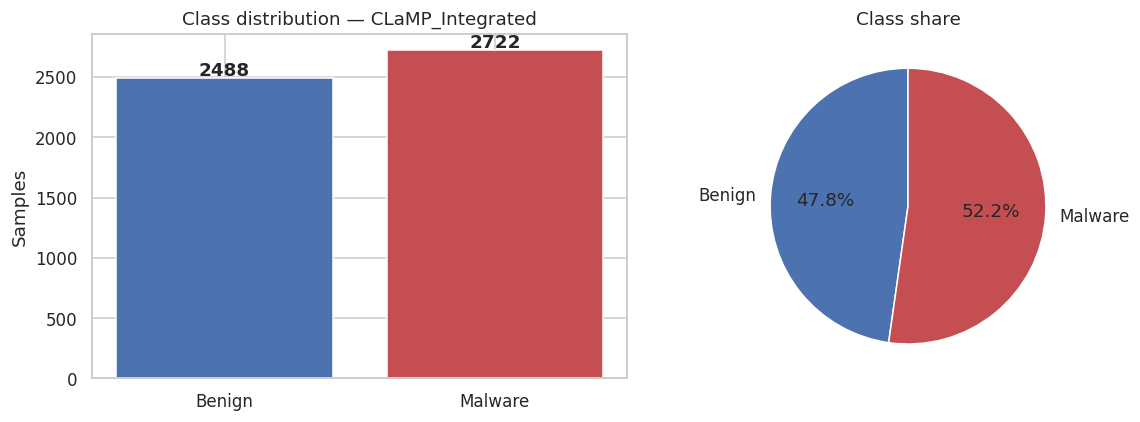

class
Benign (0)     2488
Malware (1)    2722
Name: count, dtype: int64


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = df_clamp['class'].value_counts().sort_index()
labels = ['Benign', 'Malware']
ax[0].bar(labels, counts.values, color=['#4C72B0', '#C44E52'])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
ax[0].set_title("Class distribution — CLaMP_Integrated")
ax[0].set_ylabel("Samples")
ax[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
ax[1].set_title("Class share")
plt.tight_layout()
plt.show()
print(counts.rename({0: 'Benign (0)', 1: 'Malware (1)'}))


## 1.2 Encoding & class balance

Text columns must become numbers before modeling. `packer_type` is the only non-numeric column (packer name, e.g. `NoPacker`, `UPX290...`) — `LabelEncoder` converts it to an integer code.

In [6]:
le = LabelEncoder()
for col in df_clamp.columns:
    if df_clamp[col].dtype == object or str(df_clamp[col].dtype) == 'str':
        df_clamp[col] = le.fit_transform(df_clamp[col].astype(str))

X_clamp = df_clamp.drop(columns=['class'])
y_clamp = df_clamp['class']
print("All columns numeric now:", (X_clamp.dtypes != object).all())


All columns numeric now: True


## 1.3 Splitting without leakage — 80/20 train-test, then 80/20 train-val, stratified

In [7]:
X_trainfull, X_test, y_trainfull, y_test = train_test_split(
    X_clamp, y_clamp, test_size=0.20, random_state=RANDOM_STATE, stratify=safe_stratify(y_clamp)
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainfull, y_trainfull, test_size=0.20, random_state=RANDOM_STATE, stratify=safe_stratify(y_trainfull)
)
print(f"{X_clamp.shape} full set")
print(f"{X_train.shape} train")
print(f"{X_val.shape}   val")
print(f"{X_test.shape}  test")


(5210, 69) full set
(3334, 69) train
(834, 69)   val
(1042, 69)  test


## 1.4 Avoiding feature leakage — drop near-zero-variance columns (train-only)

In [8]:
X_train, (X_val, X_test), dropped_cols = drop_low_variance(X_train, [X_val, X_test], threshold=1e-4)
print(f"Dropping low-variance cols: {len(dropped_cols)} columns removed")
print(dropped_cols)
print("Remaining features:", X_train.shape[1])


Dropping low-variance cols: 10 columns removed
['FH_char1', 'FH_char11', 'FH_char13', 'SectionAlignment', 'FileAlignment', 'OH_DLLchar3', 'OH_DLLchar5', 'OH_DLLchar6', 'OH_DLLchar9', 'OH_DLLchar10']
Remaining features: 59


## 1.5 Scaling features — fit on train only

In [9]:
sc_clamp = StandardScaler()
X_train_s = sc_clamp.fit_transform(X_train)
X_val_s = sc_clamp.transform(X_val)
X_test_s = sc_clamp.transform(X_test)
print("train fit; val/test transformed only")


train fit; val/test transformed only


## 1.6 KNN — choosing *k* on the validation set

Several *k* values are tried; each is scored by **validation AUC-ROC**. The test set is never touched during model selection.

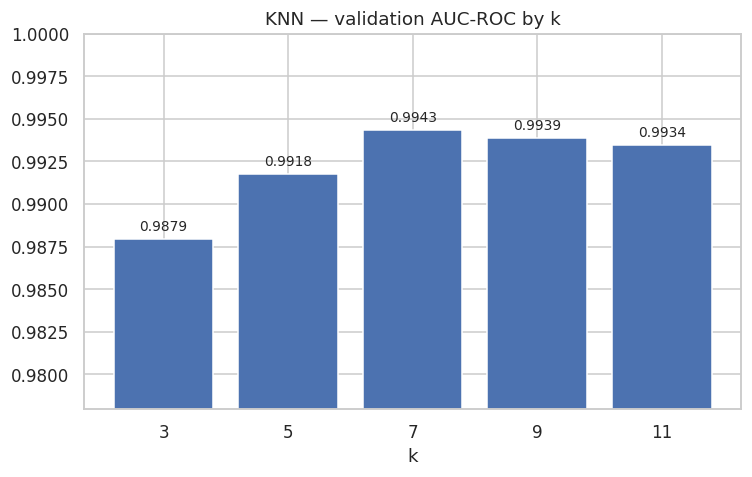

Best k = 7  (validation AUC-ROC = 0.9943)


In [10]:
k_grid = [3, 5, 7, 9, 11]
knn_val_scores = {}
for k in k_grid:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    val_auc = roc_auc_score(y_val, knn.predict_proba(X_val_s)[:, 1])
    knn_val_scores[k] = val_auc

best_k = max(knn_val_scores, key=knn_val_scores.get)
plt.figure(figsize=(7, 4.5))
plt.bar([str(k) for k in knn_val_scores], list(knn_val_scores.values()), color='#4C72B0')
for i, (k, v) in enumerate(knn_val_scores.items()):
    plt.text(i, v + 0.0005, f"{v:.4f}", ha='center', fontsize=9)
plt.title("KNN — validation AUC-ROC by k")
plt.ylim(min(knn_val_scores.values()) - 0.01, 1.0)
plt.xlabel("k")
plt.tight_layout()
plt.show()
print(f"Best k = {best_k}  (validation AUC-ROC = {knn_val_scores[best_k]:.4f})")


## 1.7 KNN — final test results (fit once, evaluate once)

In [11]:
knn_clamp = KNeighborsClassifier(n_neighbors=best_k)
knn_clamp.fit(X_train_s, y_train)
knn_clamp_pred = knn_clamp.predict(X_test_s)
knn_clamp_score = knn_clamp.predict_proba(X_test_s)[:, 1]

knn_clamp_metrics = evaluate_binary(y_test, knn_clamp_pred, knn_clamp_score)
print(f"KNN (k={best_k}) — CLaMP test results")
for k, v in knn_clamp_metrics.items():
    print(f"  {k:>10}: {v:.4f}")
print()
print(classification_report(y_test, knn_clamp_pred, target_names=['Benign', 'Malware']))


KNN (k=7) — CLaMP test results
    accuracy: 0.9674
   precision: 0.9586
      recall: 0.9798
          f1: 0.9691
     auc_roc: 0.9930

              precision    recall  f1-score   support

      Benign       0.98      0.95      0.97       498
     Malware       0.96      0.98      0.97       544

    accuracy                           0.97      1042
   macro avg       0.97      0.97      0.97      1042
weighted avg       0.97      0.97      0.97      1042



## 1.8 SVM — choosing a kernel on the validation set

`linear`, `rbf` and `poly` (degree 2) are compared with the same validation AUC-ROC selection procedure used for KNN.

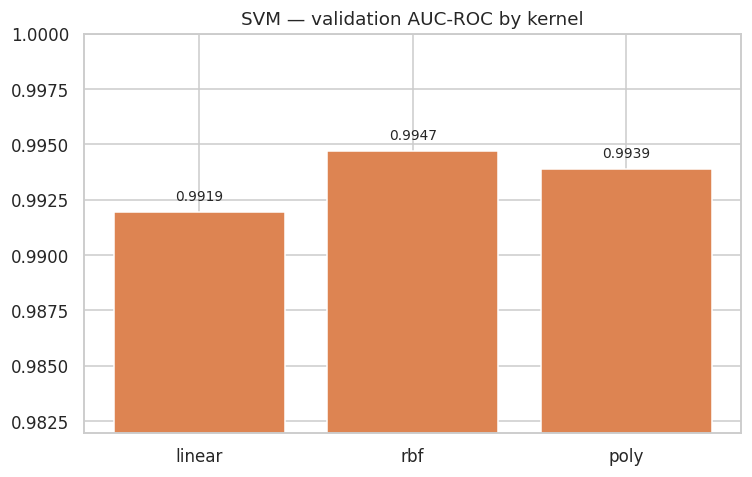

Best kernel = rbf  (validation AUC-ROC = 0.9947)


In [12]:
kernels = ['linear', 'rbf', 'poly']
svm_val_scores = {}
for kern in kernels:
    svc = SVC(kernel=kern, degree=2, probability=False, random_state=RANDOM_STATE)
    svc.fit(X_train_s, y_train)
    val_auc = roc_auc_score(y_val, svc.decision_function(X_val_s))
    svm_val_scores[kern] = val_auc

best_kernel = max(svm_val_scores, key=svm_val_scores.get)
plt.figure(figsize=(7, 4.5))
plt.bar(list(svm_val_scores.keys()), list(svm_val_scores.values()), color='#DD8452')
for i, (k, v) in enumerate(svm_val_scores.items()):
    plt.text(i, v + 0.0005, f"{v:.4f}", ha='center', fontsize=9)
plt.title("SVM — validation AUC-ROC by kernel")
plt.ylim(min(svm_val_scores.values()) - 0.01, 1.0)
plt.tight_layout()
plt.show()
print(f"Best kernel = {best_kernel}  (validation AUC-ROC = {svm_val_scores[best_kernel]:.4f})")


## 1.9 SVM — final test results

In [13]:
svm_clamp = SVC(kernel=best_kernel, degree=2, random_state=RANDOM_STATE)
svm_clamp.fit(X_train_s, y_train)
svm_clamp_pred = svm_clamp.predict(X_test_s)
svm_clamp_score = svm_clamp.decision_function(X_test_s)

svm_clamp_metrics = evaluate_binary(y_test, svm_clamp_pred, svm_clamp_score)
print(f"SVM ({best_kernel}) — CLaMP test results")
for k, v in svm_clamp_metrics.items():
    print(f"  {k:>10}: {v:.4f}")
print()
print(classification_report(y_test, svm_clamp_pred, target_names=['Benign', 'Malware']))


SVM (rbf) — CLaMP test results
    accuracy: 0.9674
   precision: 0.9521
      recall: 0.9871
          f1: 0.9693
     auc_roc: 0.9965

              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97       498
     Malware       0.95      0.99      0.97       544

    accuracy                           0.97      1042
   macro avg       0.97      0.97      0.97      1042
weighted avg       0.97      0.97      0.97      1042



## 1.10 Visualizing model performance — confusion matrices & ROC curves

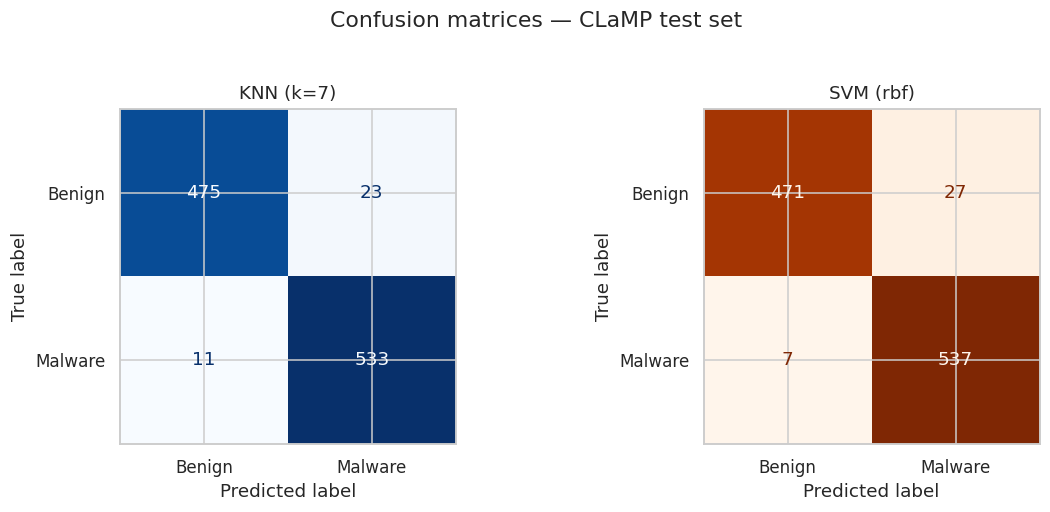

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, knn_clamp_pred, display_labels=['Benign', 'Malware'],
                                         cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f"KNN (k={best_k})")
ConfusionMatrixDisplay.from_predictions(y_test, svm_clamp_pred, display_labels=['Benign', 'Malware'],
                                         cmap='Oranges', ax=axes[1], colorbar=False)
axes[1].set_title(f"SVM ({best_kernel})")
plt.suptitle("Confusion matrices — CLaMP test set", y=1.03)
plt.tight_layout()
plt.show()


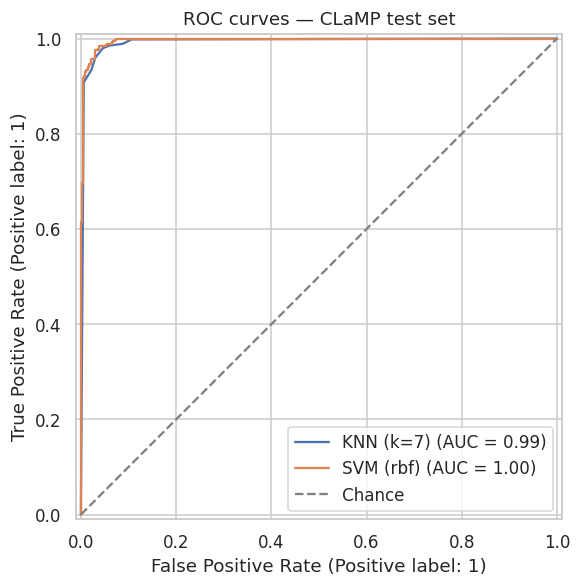

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
RocCurveDisplay.from_predictions(y_test, knn_clamp_score, name=f"KNN (k={best_k})", ax=ax, color='#4C72B0')
RocCurveDisplay.from_predictions(y_test, svm_clamp_score, name=f"SVM ({best_kernel})", ax=ax, color='#DD8452')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title("ROC curves — CLaMP test set")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 1.11 CLaMP results at a glance

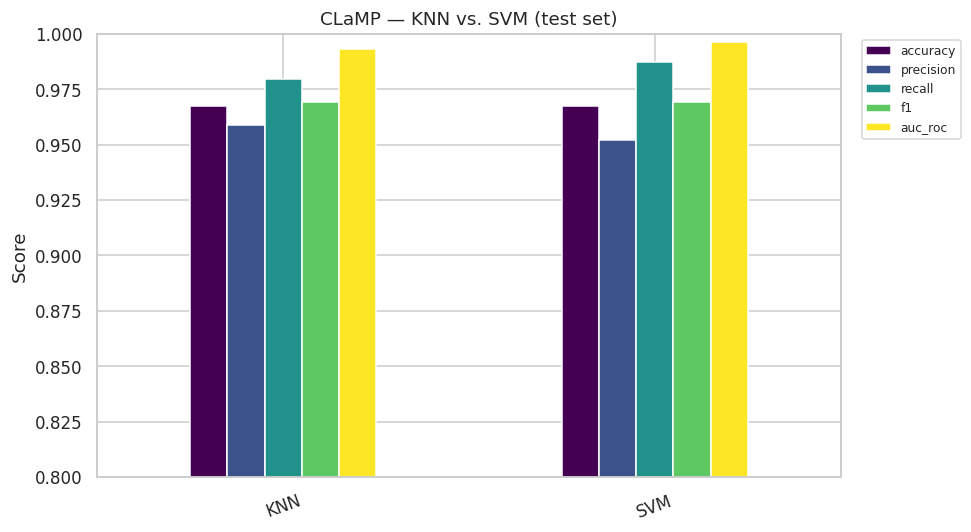

,accuracy,precision,recall,f1,auc_roc
KNN,0.9674,0.9586,0.9798,0.9691,0.9930
SVM,0.9674,0.9521,0.9871,0.9693,0.9965


In [16]:
clamp_results = pd.DataFrame({
    "KNN": knn_clamp_metrics,
    "SVM": svm_clamp_metrics,
}).T
clamp_results.plot(kind='bar', figsize=(9, 5), colormap='viridis', rot=20)
plt.title("CLaMP — KNN vs. SVM (test set)")
plt.ylabel("Score")
plt.ylim(min(0.8, clamp_results.min().min() - 0.05), 1.0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
clamp_results.style.format("{:.4f}").background_gradient(cmap="Blues", axis=0)


### Bonus — feature importance & PCA view

A quick Random Forest importance ranking, plus a PCA projection colored by the tuned KNN's predicted class, for extra intuition about which PE-header fields drive the decision.

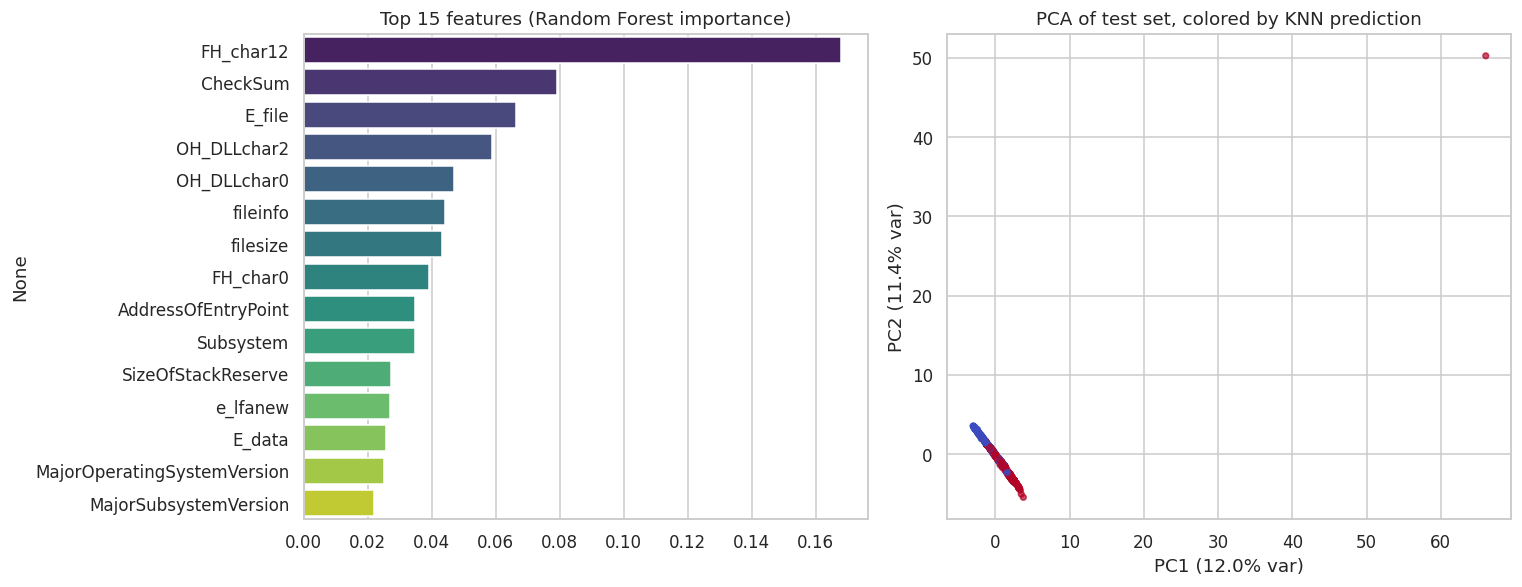

In [17]:
rf_clamp = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clamp.fit(X_train_s, y_train)
importances = pd.Series(rf_clamp.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis", ax=axes[0])
axes[0].set_title("Top 15 features (Random Forest importance)")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_test_pca = pca.fit_transform(X_test_s)
sc = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=knn_clamp_pred, cmap='coolwarm', s=14, alpha=0.7)
axes[1].set_title(f"PCA of test set, colored by KNN prediction")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.show()


---
# TASK 2 — Ransomware Detection & Family Classification
*Dynamic, Cuckoo-Sandbox behavioral features (API calls, registry/file/directory operations, dropped-file extensions, embedded strings) — binary and multiclass tasks.*


## 2.1 Preparing raw features

The raw CSV has **no header row**; column names are parsed from `VariableNames.txt` (shuffled sample order preserved as originally distributed — no reshuffling needed here since the file has no temporal structure).

In [18]:
with open("data/ransomware/VariableNames.txt", encoding="latin1") as f:
    ransom_columns = [line.strip().split(';', 1)[1] for line in f if line.strip()]

df_ransom = pd.read_csv("data/ransomware/RansomwareData.csv", header=None)
df_ransom.columns = ransom_columns
print("columns.shape ->", (len(ransom_columns),))

family_names = {
    0: 'Goodware', 1: 'Critroni', 2: 'CryptLocker', 3: 'CryptoWall', 4: 'KOLLAH',
    5: 'Kovter', 6: 'Locker', 7: 'MATSNU', 8: 'PGPCODER', 9: 'Reveton',
    10: 'TeslaCrypt', 11: 'Trojan-Ransom'
}
print(f"{len(family_names)} family names loaded")
df_ransom.head()


columns.shape -> (30970,)
12 family names loaded


,ID,Label (1 Ransomware / 0 Goodware),Ransomware Family,API:GetSystemDirectoryA,API:WriteConsoleA,API:NtOpenFile,API:NtCreateProcessEx,API:GetSystemInfo,API:WriteConsoleW,API:NtReadVirtualMemory,...,STR:16258;eclipse/features/org.eclipse.aether.transport.http.feature_1.0.1.v20141111/META-INF/ECLIPSE_.RSA,"STR:16259; <string lang=""en"" key=""ALGO_NOT_SUPPORTED_FOR_SYS_ENCRYPTION"">This algorithm is currently not supported for system encryption.</string>",STR:16260;CRYPTO: Certificate: Failed to translate key to ncrypt storage provider,STR:16261;QSQL Prompt_7.0.0.62_x86\Red Gate\SQL Prompt 7\ActiproSoftware.WinUICore.Net20.dll,STR:16262;Klik op Voltooien om door te gaan.AdminUserExitFormAdminFatalErrorFormAdminMaintenanceFormAdminResumeFormAdminWelcomeFormNextButton&Volgende >WelcomeTextHet installatieprogramma leidt u door de stappen die nodig zijn om [ProductName] op deze computer te installeren.{\TahomaBold12}De wizard Netwerk instellen van [ProductName]CopyrightWarningTextWaarschuwing: dit computerprogramma is auteursrechtelijk beschermd. Onrechtmatige verveelvoudiging of distributie van dit programma of een gedeelte ervan is verboden en strafbaar,STR:16263;MP_PERSISTEDSTORE_NOTIFY_DISABLE,STR:16264;disassembling,STR:16265;IPRT_LOCK_VALIDATOR_STRICT_ORDER,STR:16266;zFormO.dll,STR:16267;SETUP_FAILED_BOOT_DRIVE_ENCRYPTED_DOWNGRADE
0,10001,1,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10002,1,3,1,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,10003,1,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,10005,1,5,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,10006,1,7,1,0,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [19]:
print("Shape:", df_ransom.shape)
print(df_ransom['Label (1 Ransomware / 0 Goodware)'].value_counts().rename({0: 'Goodware', 1: 'Ransomware'}))
fam_counts = df_ransom['Ransomware Family'].map(family_names).value_counts()
print()
print(fam_counts)


Shape: (1524, 30970)
Label (1 Ransomware / 0 Goodware)
Goodware      942
Ransomware    582
Name: count, dtype: int64

Ransomware Family
Goodware         942
CryptLocker      107
Locker            97
Reveton           90
Kovter            64
MATSNU            59
Critroni          50
CryptoWall        46
Trojan-Ransom     34
KOLLAH            25
TeslaCrypt         6
PGPCODER           4
Name: count, dtype: int64


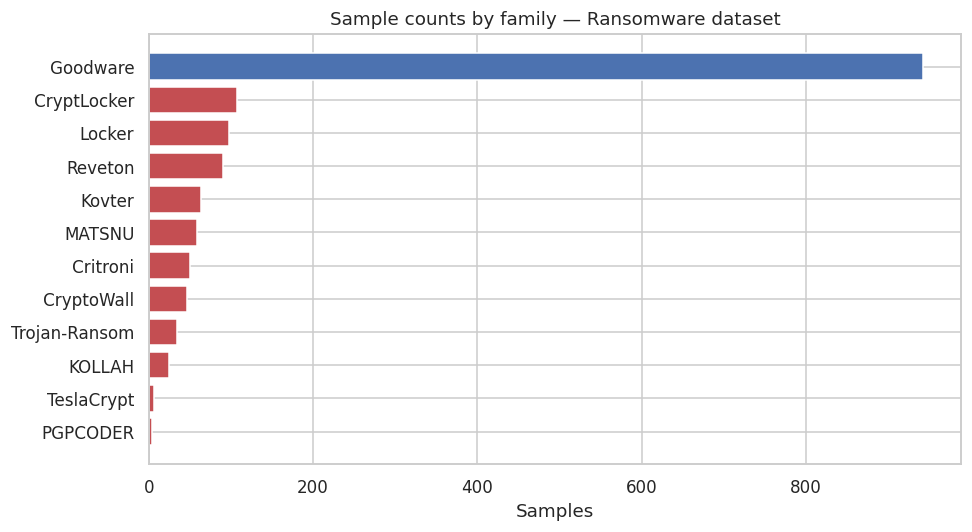

Rarest class: PGPCODER (4 samples)


In [20]:
plt.figure(figsize=(9, 5))
order = fam_counts.sort_values(ascending=True)
colors = ['#4C72B0' if name == 'Goodware' else '#C44E52' for name in order.index]
plt.barh(order.index, order.values, color=colors)
plt.title("Sample counts by family — Ransomware dataset")
plt.xlabel("Samples")
plt.tight_layout()
plt.show()
print(f"Rarest class: {fam_counts.idxmin()} ({fam_counts.min()} samples)")


## 2.2 Dropping constant columns

Many of the 30,966 behavioral flags never fire in this sample and carry no information.

In [21]:
X_ransom_full = df_ransom.drop(columns=['ID', 'Label (1 Ransomware / 0 Goodware)', 'Ransomware Family'])
y_bin_full = df_ransom['Label (1 Ransomware / 0 Goodware)']
y_multi_full = df_ransom['Ransomware Family']

from collections import Counter
nunique_counts = X_ransom_full.nunique()
print(Counter(nunique_counts.values))


Counter({np.int64(2): 23616, np.int64(1): 7351})


## 2.3 Binary task: Ransomware vs. Goodware (0 = Goodware, 1 = Ransomware)

Same 80/20 → 80/20, stratified, train-only leakage-safe preprocessing pipeline as Task 1.

In [22]:
Xb_trainfull, Xb_test, yb_trainfull, yb_test = train_test_split(
    X_ransom_full, y_bin_full, test_size=0.20, random_state=RANDOM_STATE, stratify=safe_stratify(y_bin_full)
)
Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    Xb_trainfull, yb_trainfull, test_size=0.20, random_state=RANDOM_STATE, stratify=safe_stratify(yb_trainfull)
)
Xb_train, (Xb_val, Xb_test), dropped_b = drop_low_variance(Xb_train, [Xb_val, Xb_test], threshold=1e-6)

print("Label counts:", dict(y_bin_full.value_counts()))
print(f"train {Xb_train.shape[0]} \u00b7 val {Xb_val.shape[0]} \u00b7 test {Xb_test.shape[0]}")
print(f"Features kept: {Xb_train.shape[1]} (dropped {len(dropped_b)} constant columns)")


Label counts: {0: np.int64(942), 1: np.int64(582)}
train 975 · val 244 · test 305
Features kept: 17308 (dropped 13659 constant columns)


## 2.4 Binary: KNN vs. SVM

With 30,000+ raw features, high dimensionality changes which model wins: KNN's distance metric degrades ("curse of dimensionality"), while SVM's margin-based decision boundary tends to cope better. No scaling is applied here — features are already binary 0/1 flags.

In [23]:
Xb_train_v = Xb_train.values.astype(np.float32)
Xb_val_v = Xb_val.values.astype(np.float32)
Xb_test_v = Xb_test.values.astype(np.float32)

# --- KNN: pick k on validation AUC-ROC ---
knn_bin_val = {}
for k in k_grid:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xb_train_v, yb_train)
    knn_bin_val[k] = roc_auc_score(yb_val, knn.predict_proba(Xb_val_v)[:, 1])
best_k_bin = max(knn_bin_val, key=knn_bin_val.get)

knn_ransom_bin = KNeighborsClassifier(n_neighbors=best_k_bin)
knn_ransom_bin.fit(Xb_train_v, yb_train)
knn_bin_pred = knn_ransom_bin.predict(Xb_test_v)
knn_bin_score = knn_ransom_bin.predict_proba(Xb_test_v)[:, 1]
knn_bin_metrics = evaluate_binary(yb_test, knn_bin_pred, knn_bin_score)

# --- SVM: pick kernel on validation AUC-ROC ---
svm_bin_val = {}
for kern in kernels:
    svc = SVC(kernel=kern, degree=2, random_state=RANDOM_STATE)
    svc.fit(Xb_train_v, yb_train)
    svm_bin_val[kern] = roc_auc_score(yb_val, svc.decision_function(Xb_val_v))
best_kernel_bin = max(svm_bin_val, key=svm_bin_val.get)

svm_ransom_bin = SVC(kernel=best_kernel_bin, degree=2, random_state=RANDOM_STATE)
svm_ransom_bin.fit(Xb_train_v, yb_train)
svm_bin_pred = svm_ransom_bin.predict(Xb_test_v)
svm_bin_score = svm_ransom_bin.decision_function(Xb_test_v)
svm_bin_metrics = evaluate_binary(yb_test, svm_bin_pred, svm_bin_score)

print(f"Best k (KNN): {best_k_bin}  | Best kernel (SVM): {best_kernel_bin}")
print()
print("KNN test metrics:", {k: round(v, 4) for k, v in knn_bin_metrics.items()})
print("SVM test metrics:", {k: round(v, 4) for k, v in svm_bin_metrics.items()})


Best k (KNN): 7  | Best kernel (SVM): rbf

KNN test metrics: {'accuracy': 0.8951, 'precision': 0.8333, 'recall': 0.9052, 'f1': 0.8678, 'auc_roc': 0.9704}
SVM test metrics: {'accuracy': 0.9344, 'precision': 0.8692, 'recall': 0.9741, 'f1': 0.9187, 'auc_roc': 0.9932}


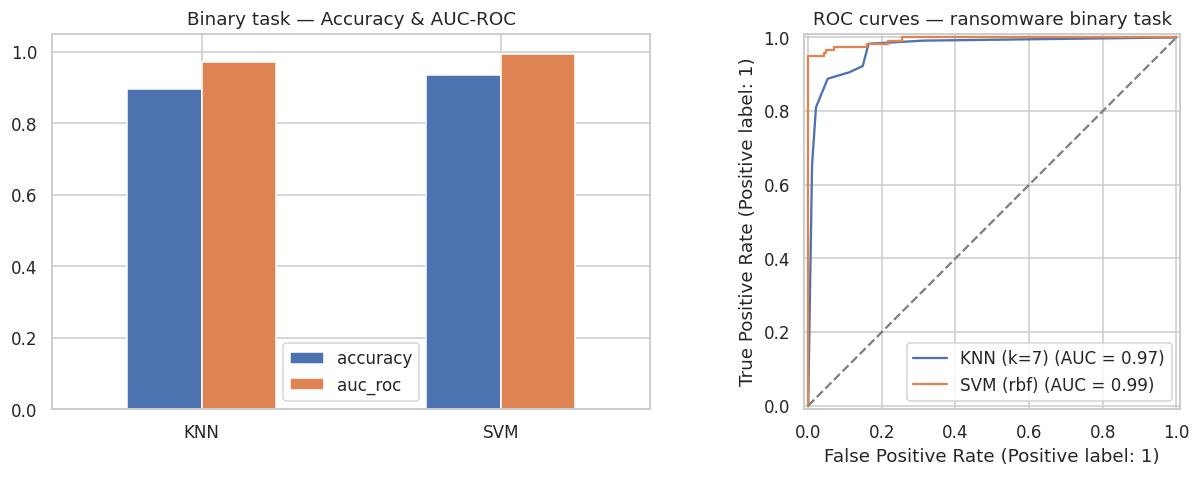

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
bars = pd.DataFrame({"KNN": knn_bin_metrics, "SVM": svm_bin_metrics}).T[['accuracy', 'auc_roc']]
bars.plot(kind='bar', ax=ax[0], color=['#4C72B0', '#DD8452'], rot=0)
ax[0].set_title("Binary task — Accuracy & AUC-ROC")
ax[0].set_ylim(0, 1.05)

RocCurveDisplay.from_predictions(yb_test, knn_bin_score, name=f"KNN (k={best_k_bin})", ax=ax[1], color='#4C72B0')
RocCurveDisplay.from_predictions(yb_test, svm_bin_score, name=f"SVM ({best_kernel_bin})", ax=ax[1], color='#DD8452')
ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
ax[1].set_title("ROC curves — ransomware binary task")
plt.tight_layout()
plt.show()


## 2.5 Multiclass task: 12 ransomware families

Same features, `y` = family name instead of binary label. Model selection uses **macro-F1** (weighs every family equally, including the 4-sample `PGPCODER` class) rather than accuracy, which would be dominated by the large `Goodware` class.

In [25]:
Xm_trainfull, Xm_test, ym_trainfull, ym_test = train_test_split(
    X_ransom_full, y_multi_full, test_size=0.20, random_state=RANDOM_STATE, stratify=safe_stratify(y_multi_full)
)
Xm_train, Xm_val, ym_train, ym_val = train_test_split(
    Xm_trainfull, ym_trainfull, test_size=0.20, random_state=RANDOM_STATE, stratify=safe_stratify(ym_trainfull)
)
Xm_train, (Xm_val, Xm_test), dropped_m = drop_low_variance(Xm_train, [Xm_val, Xm_test], threshold=1e-6)

Xm_train_v = Xm_train.values.astype(np.float32)
Xm_val_v = Xm_val.values.astype(np.float32)
Xm_test_v = Xm_test.values.astype(np.float32)

print(f"train {Xm_train.shape[0]} \u00b7 val {Xm_val.shape[0]} \u00b7 test {Xm_test.shape[0]}")
print("Train class counts:")
print(ym_train.map(family_names).value_counts())


train 975 · val 244 · test 305
Train class counts:
Ransomware Family
Goodware         602
CryptLocker       69
Locker            62
Reveton           57
Kovter            41
MATSNU            38
Critroni          32
CryptoWall        30
Trojan-Ransom     22
KOLLAH            16
TeslaCrypt         4
PGPCODER           2
Name: count, dtype: int64


In [26]:
all_classes = sorted(y_multi_full.unique())

# --- KNN multiclass ---
knn_multi_val = {}
for k in k_grid:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xm_train_v, ym_train)
    proba = pd.DataFrame(knn.predict_proba(Xm_val_v), columns=knn.classes_).reindex(columns=all_classes, fill_value=0).values
    knn_multi_val[k] = f1_score(ym_val, knn.predict(Xm_val_v), average='macro', zero_division=0)
best_k_multi = max(knn_multi_val, key=knn_multi_val.get)

knn_ransom_multi = KNeighborsClassifier(n_neighbors=best_k_multi)
knn_ransom_multi.fit(Xm_train_v, ym_train)
knn_multi_pred = knn_ransom_multi.predict(Xm_test_v)
knn_multi_proba = pd.DataFrame(knn_ransom_multi.predict_proba(Xm_test_v), columns=knn_ransom_multi.classes_).reindex(columns=all_classes, fill_value=0).values
knn_multi_metrics = evaluate_multiclass(ym_test, knn_multi_pred, knn_multi_proba, all_classes)

# --- SVM multiclass (kernels compared on validation macro-F1) ---
svm_multi_val = {}
for kern in kernels:
    svc = SVC(kernel=kern, degree=2, decision_function_shape='ovr', random_state=RANDOM_STATE)
    svc.fit(Xm_train_v, ym_train)
    svm_multi_val[kern] = f1_score(ym_val, svc.predict(Xm_val_v), average='macro', zero_division=0)
best_kernel_multi = max(svm_multi_val, key=svm_multi_val.get)

svm_ransom_multi = SVC(kernel=best_kernel_multi, degree=2, decision_function_shape='ovr', random_state=RANDOM_STATE)
svm_ransom_multi.fit(Xm_train_v, ym_train)
svm_multi_pred = svm_ransom_multi.predict(Xm_test_v)
svm_multi_score = pd.DataFrame(svm_ransom_multi.decision_function(Xm_test_v), columns=svm_ransom_multi.classes_).reindex(columns=all_classes, fill_value=0).values
svm_multi_proba = softmax_rows(svm_multi_score)  # roc_auc_score(multi_class='ovr') needs rows that sum to 1
svm_multi_metrics = evaluate_multiclass(ym_test, svm_multi_pred, svm_multi_proba, all_classes)

print(f"Best k (KNN, by val macro-F1): {best_k_multi}  | Best kernel (SVM, by val macro-F1): {best_kernel_multi}")
print()
print("KNN test metrics:", {k: round(v, 4) if v==v else v for k, v in knn_multi_metrics.items()})
print("SVM test metrics:", {k: round(v, 4) if v==v else v for k, v in svm_multi_metrics.items()})


Best k (KNN, by val macro-F1): 3  | Best kernel (SVM, by val macro-F1): linear

KNN test metrics: {'accuracy': 0.7836, 'precision_macro': 0.4522, 'recall_macro': 0.4252, 'f1_macro': 0.4258, 'auc_roc_macro': 0.7886}
SVM test metrics: {'accuracy': 0.8623, 'precision_macro': 0.5755, 'recall_macro': 0.5637, 'f1_macro': 0.5648, 'auc_roc_macro': 0.8144}


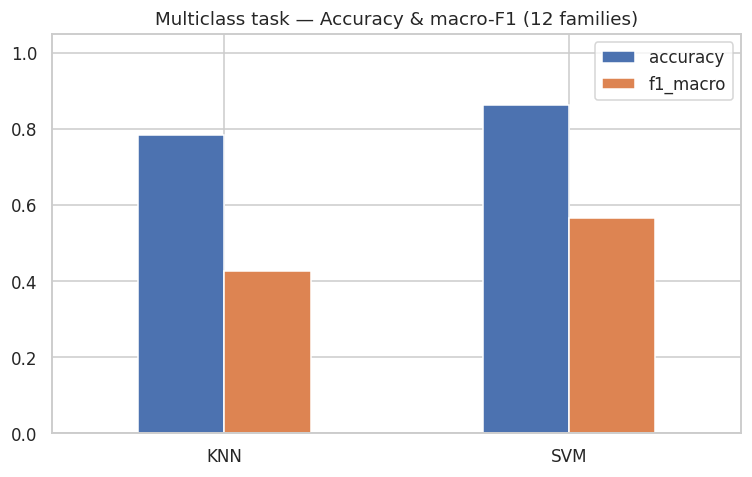

In [27]:
bars = pd.DataFrame({"KNN": knn_multi_metrics, "SVM": svm_multi_metrics}).T[['accuracy', 'f1_macro']]
bars.plot(kind='bar', figsize=(7, 4.5), color=['#4C72B0', '#DD8452'], rot=0)
plt.title("Multiclass task — Accuracy & macro-F1 (12 families)")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 2.6 Multiclass ROC curves — one-vs-rest, all 12 families

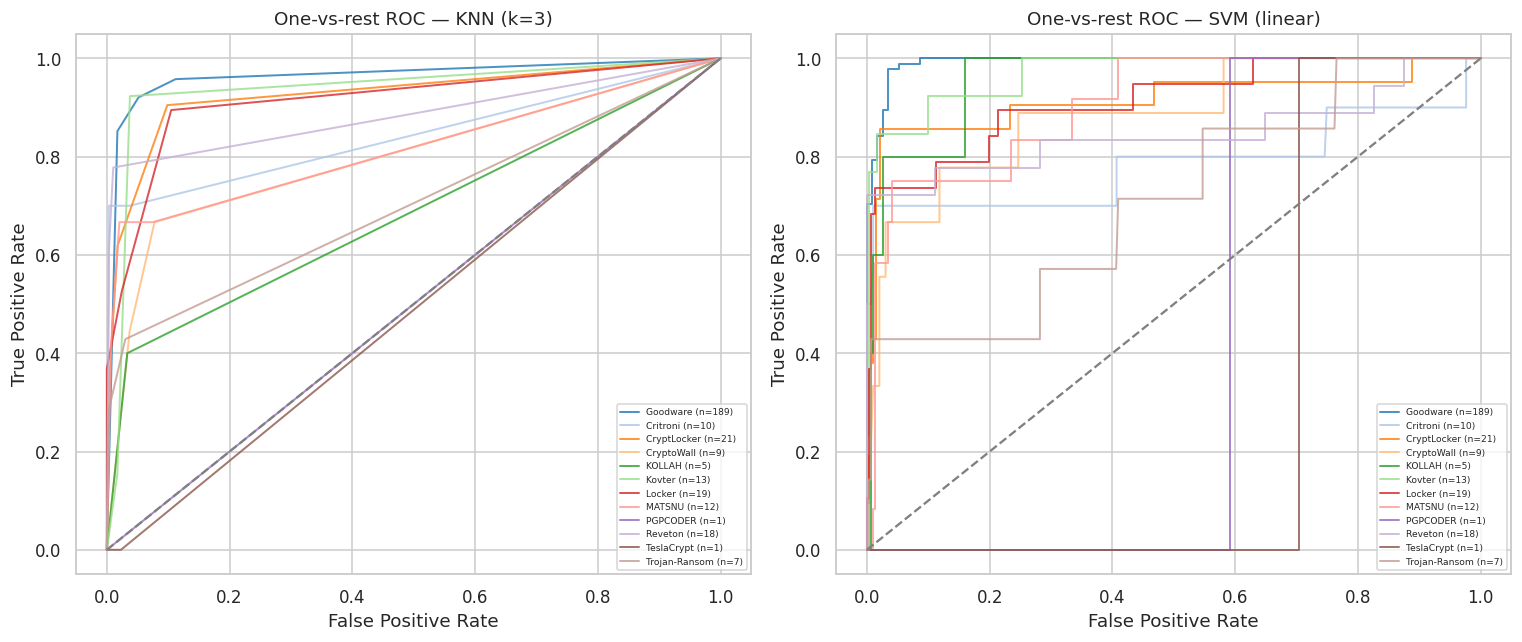

12 curves per model, one per family. Goodware (largest class) is typically clean; rare families are noisier.


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = sns.color_palette("tab20", len(all_classes))

for ax, (pred, score, title) in zip(
    axes,
    [(knn_multi_pred, knn_multi_proba, f"KNN (k={best_k_multi})"),
     (svm_multi_pred, svm_multi_score, f"SVM ({best_kernel_multi})")]
):
    for i, cls in enumerate(all_classes):
        y_bin_cls = (ym_test == cls).astype(int)
        if y_bin_cls.sum() == 0:
            continue  # class absent from this test split
        fpr, tpr, _ = roc_curve(y_bin_cls, score[:, i])
        ax.plot(fpr, tpr, color=palette[i], alpha=0.8, linewidth=1.3,
                label=f"{family_names[cls]} (n={y_bin_cls.sum()})")
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(f"One-vs-rest ROC — {title}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=6, loc='lower right', ncol=1)

plt.tight_layout()
plt.show()
print("12 curves per model, one per family. Goodware (largest class) is typically clean; rare families are noisier.")


## 2.7 Ransomware results at a glance

In [29]:
ransom_summary = pd.DataFrame({
    "KNN (binary)": {k: knn_bin_metrics.get(k, np.nan) for k in ['accuracy', 'auc_roc', 'f1']},
    "SVM (binary)": {k: svm_bin_metrics.get(k, np.nan) for k in ['accuracy', 'auc_roc', 'f1']},
    "KNN (multiclass)": {'accuracy': knn_multi_metrics['accuracy'], 'auc_roc': knn_multi_metrics['auc_roc_macro'], 'f1': knn_multi_metrics['f1_macro']},
    "SVM (multiclass)": {'accuracy': svm_multi_metrics['accuracy'], 'auc_roc': svm_multi_metrics['auc_roc_macro'], 'f1': svm_multi_metrics['f1_macro']},
}).T
ransom_summary.columns = ['accuracy', 'auc_roc (macro if multi)', 'f1 (macro if multi)']
ransom_summary.style.format("{:.4f}").background_gradient(cmap="Oranges", axis=0)


,accuracy,auc_roc (macro if multi),f1 (macro if multi)
KNN (binary),0.8951,0.9704,0.8678
SVM (binary),0.9344,0.9932,0.9187
KNN (multiclass),0.7836,0.7886,0.4258
SVM (multiclass),0.8623,0.8144,0.5648


---
# Combined Results & Key Takeaways


## Saving combined results — one row per model × dataset × task

In [30]:
def flatten(name, dataset, task, metrics):
    row = {"model": name, "dataset": dataset, "task": task}
    row.update(metrics)
    return row

all_results = pd.DataFrame([
    flatten("KNN", "CLaMP", "binary", knn_clamp_metrics),
    flatten("SVM", "CLaMP", "binary", svm_clamp_metrics),
    flatten("KNN", "Ransomware", "binary", knn_bin_metrics),
    flatten("SVM", "Ransomware", "binary", svm_bin_metrics),
    flatten("KNN", "Ransomware", "multiclass", knn_multi_metrics),
    flatten("SVM", "Ransomware", "multiclass", svm_multi_metrics),
])
all_results.to_csv("results_lab_knn_svm.csv", index=False)
print("results_lab_knn_svm.csv written —", all_results.shape[0], "rows")
all_results


results_lab_knn_svm.csv written — 6 rows


,model,dataset,task,accuracy,precision,recall,f1,auc_roc,precision_macro,recall_macro,f1_macro,auc_roc_macro
0,KNN,CLaMP,binary,0.967370,0.958633,0.979779,0.969091,0.992981,NaN,NaN,NaN,NaN
1,SVM,CLaMP,binary,0.967370,0.952128,0.987132,0.969314,0.996497,NaN,NaN,NaN,NaN
2,KNN,Ransomware,binary,0.895082,0.833333,0.905172,0.867769,0.970421,NaN,NaN,NaN,NaN
3,SVM,Ransomware,binary,0.934426,0.869231,0.974138,0.918699,0.993204,NaN,NaN,NaN,NaN
4,KNN,Ransomware,multiclass,0.783607,NaN,NaN,NaN,NaN,0.452162,0.425175,0.425814,0.788629
5,SVM,Ransomware,multiclass,0.862295,NaN,NaN,NaN,NaN,0.575501,0.563739,0.564834,0.814448


## Key takeaways

- **Guard the test set.** Model selection (k, kernel) happens on the *validation* set only; the test set is scored exactly once per model, at the end.
- **Silent leakage is real.** Near-zero-variance columns, and the `StandardScaler`, are always fit on `X_train` only, then applied unchanged to validation/test.
- **High dimensionality hurts KNN.** On CLaMP (69 features) KNN and SVM are close, near-ceiling. On the Ransomware dataset (30,966 raw features) SVM's margin-based boundary tends to handle the "curse of dimensionality" far better than KNN's raw Euclidean distance.
- **Stratify, safely.** `safe_stratify()` keeps rare classes (down to 4 samples for `PGPCODER`) from crashing `train_test_split`, falling back to a plain split only when necessary.
- **Match the metric to the task.** Accuracy is misleading under class imbalance — AUC-ROC for the binary tasks, macro-F1 for the 12-way multiclass task (so `PGPCODER` counts as much as `Goodware`).
- **Security is a classification task.** Both malware detection (CLaMP) and ransomware family attribution reduce cleanly to a supervised-learning pipeline: load → prep → train/tune → evaluate.

## References
1. Kumar, A. et al. — [`urwithajit9/ClaMP`](https://github.com/urwithajit9/ClaMP) — ClaMP dataset & feature engineering.
2. Sgandurra, D., Muñoz-González, L., Mohsen, R., Lupu, E.C. (2016) — *"Automated Dynamic Analysis of Ransomware: Benefits, Limitations and use for Detection"*, arXiv:1609.03020 — dataset mirrored at [`rissgrouphub/ransomwaredataset2016`](https://github.com/rissgrouphub/ransomwaredataset2016).
3. `smhuda/malware-detection-ml`, `fun-personal-projects/Malware-detection-using-Machine-Learning`, `aus36/ML-Malware-Classification` — staged KNN-vs-others notebook patterns referenced in the earlier CLaMP-only notebook.
4. Ayinla et al. — *"Detailed Analyses and Efficient Identification of Malware Evidence in CLaMP Dataset based on Machine Learning Approaches."*
5. PAIC / Pattern Recognition Lab — *"Applications of AI in Cyber Security: Malware & Ransomware Classification with KNN and SVM"* workshop lab guide (uploaded PDF), used as the structural reference for this notebook's 6-stage pipeline.

**Files bundled with this notebook** (in `data/`):
- `ClaMP_Integrated-5184.csv`, `ClaMP_Raw-5184.csv` — Task 1
- `ransomware/RansomwareData.csv`, `ransomware/VariableNames.txt`, `ransomware/Family Names ID.txt`, `ransomware/README.txt` — Task 2
